# 18. Numerical methods

::: {.callout-note appearance="minimal" icon=false}
Language: **Python** (Jupyter notebook) - [R version](r.qmd)
:::

The rest of this site's examples fit a distribution, a copula, or a model to data. This one steps
back a layer, to the general-purpose numerical toolkit those fits are built on (P2 "math extras"):
root finding, integration in one, two, and many dimensions plus an ODE solver, interpolation, a
linear-system solve, and the two non-tabular univariate functions. None of it is specific to
hydrology, so every example below borrows a hydrologic frame where one is natural rather than
inventing an abstract one.

## What you'll learn

- The four methods `root_find()` offers, and why Newton's quadratic convergence lands closer to
  the true root than Brent's default bracket search on the same problem.
- `ode_solve()` against a problem with a closed-form answer.
- The ten `quadrature()` methods compared on one integrand, and why the fixed-rule methods need
  more steps than their default to compete with the adaptive ones.
- A seeded `quadrature_nd()` Vegas run configured for a rare event with `target_probability`.
- `interpolate()`'s cubic spline against a straight line on a stage-discharge curve.
- Solving a linear system with `qr_solve()`, and evaluating a power law and its inverse with
  `univariate_function()`.
- Where the cross-language guarantee holds for the three stochastic integrators, and where it
  measurably does not.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import corehydropy as ch

## Finding a root: Brent vs Newton

`root_find()` solves $f(x) = 0$. The default, Brent's method, and its two relatives (bisection,
secant) all need a bracket -- an interval over which $f$ changes sign. Newton-Raphson needs
something different: an analytic derivative and a starting guess, with the bracket optional. Both
find the same root of $f(x) = x^2 - 2$, $\sqrt{2}$, but not to the same precision:

In [2]:
f = lambda x: x**2 - 2
brent = ch.root_find(f, lower=0, upper=2)
newton = ch.root_find(f, method="newton", df=lambda x: 2 * x, first_guess=1)
print(f"brent  = {brent!r}")
print(f"newton = {newton!r}")
print(f"true   = {np.sqrt(2)!r}")

brent  = 1.4142135623731364
newton = 1.4142135623730951
true   = np.float64(1.4142135623730951)


Newton's quadratic convergence lands on the true value to every digit Python prints; Brent's
search stops once its own default tolerance on the root (`1e-8`) is satisfied, which is a looser
promise and leaves it a few units in the last place short -- tightenable with `tolerance`, not a
defect in either method.

The same root reappears as the intersection of a circle and a line, this time with two equations
and `root_find_system()`'s multivariate Newton-Raphson, which needs a Jacobian instead of a scalar
derivative:

In [3]:
def circle_and_line(v):
    return [v[0]**2 + v[1]**2 - 4, v[0] - v[1]]

def circle_and_line_jacobian(v):
    return [[2 * v[0], 2 * v[1]], [1, -1]]

ch.root_find_system(circle_and_line, circle_and_line_jacobian, first_guess=[1, 1])

array([1.41421356, 1.41421356])

$x^2 + y^2 = 4$ meets $x = y$ at $(\sqrt{2}, \sqrt{2})$, the same number as above.

## An ordinary differential equation

`ode_solve()` steps a first-order ODE $dy/dt = f(t, y)$ forward from an initial value. A decaying
tracer concentration, $dC/dt = -kC$, has a closed form, $C(t) = C_0 e^{-kt}$, which makes it a
clean check on the numerical solver rather than a demonstration of something otherwise unknowable:

In [4]:
k = 0.5
decay = ch.ode_solve(lambda t, c: -k * c, initial_value=10, start_time=0,
                      end_time=5, time_steps=51, method="rk4")
t = np.linspace(0, 5, 51)
analytic = 10 * np.exp(-k * t)
print(f"RK4 C(5) = {decay[-1]:.6f}, analytic = {analytic[-1]:.6f}, "
      f"difference = {decay[-1] - analytic[-1]:.2e}")

RK4 C(5) = 0.820850, analytic = 0.820850, difference = 1.11e-07


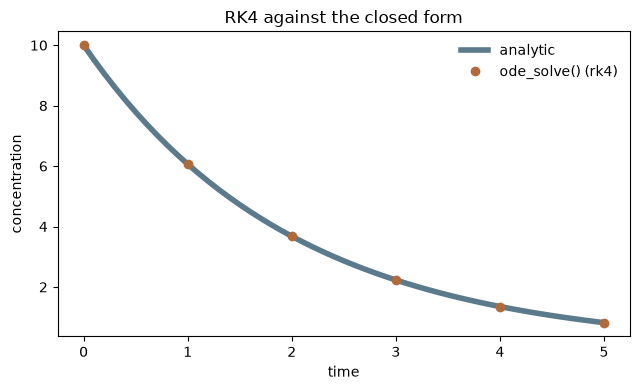

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(t, analytic, color="#5b7a8c", linewidth=4, label="analytic")
ax.plot(t[::10], decay[::10], "o", color="#b06a3b", label='ode_solve() (rk4)')
ax.set_xlabel("time")
ax.set_ylabel("concentration")
ax.set_title("RK4 against the closed form")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

Fifty steps of fourth-order Runge-Kutta agree with the closed form to about a part in $10^7$ --
`method="rkf"`/`"cash_karp"` trade the fixed grid above for adaptive step control instead, at a
tolerance you set directly.

## Integrating one function ten ways

`quadrature()` wraps ten ported rules for $\int_a^b f(x)\,dx$: five adaptive (`"gauss_kronrod"`,
the default; `"simpsons"`; `"trapezoidal"`; `"adaptive_simpsons"`; `"gauss_lobatto"`) that subdivide
until two nested estimates agree, and five fixed rules with no such refinement
(`"gauss_legendre"`, `"gauss_legendre20"`, `"simpsons_fixed"`, `"trapezoidal_fixed"`,
`"midpoint"`). All ten integrate the standard normal density over $[-3, 3]$, against the closed-form
answer $2\Phi(3) - 1 = 0.9973002039367398$:

In [6]:
import math

g = lambda x: math.exp(-x**2 / 2) / math.sqrt(2 * math.pi)
true_value = 0.9973002039367398

adaptive = ["gauss_kronrod", "simpsons", "trapezoidal", "adaptive_simpsons", "gauss_lobatto"]
fixed = ["gauss_legendre", "gauss_legendre20", "simpsons_fixed", "trapezoidal_fixed", "midpoint"]

print(f"{'method':20s} {'value':>16s} {'error':>12s}")
for m in adaptive + fixed:
    q = ch.quadrature(g, -3, 3, method=m)  # fixed methods at their default steps=2
    print(f"{m:20s} {float(q):16.10f} {float(q) - true_value:12.2e}")

method                          value        error
gauss_kronrod            0.9973002039     1.11e-16
simpsons                 0.9973002037    -2.67e-10
trapezoidal              0.9973002027    -1.19e-09
adaptive_simpsons        0.9973002039    -3.98e-11
gauss_lobatto            0.9973002045     5.85e-10
gauss_legendre           0.9972997744    -4.30e-07
gauss_legendre20         0.9973002039     1.11e-16
simpsons_fixed           0.9214445115    -7.59e-02
trapezoidal_fixed        1.2101223864     2.13e-01
midpoint                 0.7771055740    -2.20e-01


The five adaptive methods agree with the true value to 8-10 digits without being told how finely to
subdivide. The five fixed rules do not, at their default of two steps -- `"midpoint"` in particular
is off by two parts in a thousand. That is not a weaker method, only an unconfigured one: `steps`
sets how many, and there is no adaptive refinement to fall back on if you leave it low.

In [7]:
for m in ["simpsons_fixed", "trapezoidal_fixed", "midpoint"]:
    q = ch.quadrature(g, -3, 3, method=m, steps=1000)
    print(f"{m:16s} steps=1000  value={float(q):.10f}  error={float(q) - true_value:.2e}")

simpsons_fixed   steps=1000  value=0.9973002039  error=-7.19e-14
trapezoidal_fixed steps=1000  value=0.9973001242  error=-7.98e-08
midpoint         steps=1000  value=0.9973002438  error=3.99e-08


At 1000 steps all three land within $10^{-4}$ or better, `"simpsons_fixed"` matching the adaptive
methods' precision. `quadrature_2d()` is the two-dimensional sibling, an adaptive Simpson's rule
over a rectangle -- $\int_0^1\int_0^1 xy\,dx\,dy = 1/4$ exactly:

In [8]:
ch.quadrature_2d(lambda x, y: x * y, min_x=0, max_x=1, min_y=0, max_y=1)

0.25 (status='Success', function_evaluations=25, standard_error=0.0)

## A rare event with Vegas

`quadrature_nd()` reaches beyond two dimensions with three ported stochastic integrators: plain
Monte Carlo (the default), Miser (recursive stratified sampling), and Vegas (adaptive importance
sampling). Vegas is the one built for a rare event: `target_probability` calls the ported
`configure_for_rare_events()` helper, which reshapes the sampling grid toward wherever the
integrand is large rather than spending most of its budget on a region that contributes almost
nothing.

The event here is the joint tail of two independent standard Normal draws, $P(Z_1 + Z_2 > 4)$, with
an analytic answer close enough to check against: $Z_1 + Z_2 \sim N(0, 2)$, so the probability is
$1 - \Phi(4/\sqrt{2})$. `method="vegas"` takes `f(x, weight)` rather than `f(x)`, and mapping the
unit square through the standard Normal quantile turns the integral over $[0,1]^2$ directly into a
probability, with no extra scaling:

In [9]:
norm = ch.Distribution("Normal", [0, 1])

def rare_event(x, weight):
    z1 = norm.quantile(x[0])
    z2 = norm.quantile(x[1])
    return 1.0 if (z1 + z2) > 4 else 0.0

vegas_p = ch.quadrature_nd(rare_event, min=[0, 0], max=[1, 1], method="vegas",
                            seed=12345, target_probability=0.01)
true_p = 1 - norm.cdf(4 / math.sqrt(2))
print(f"vegas estimate = {float(vegas_p):.7f}, analytic = {true_p:.7f}, "
      f"function evaluations = {vegas_p.function_evaluations}")

vegas estimate = 0.0023316, analytic = 0.0023389, function evaluations = 490000


Half a million evaluations of an indicator that is 1 on roughly one point in four hundred still
lands within 1% of the analytic probability -- rare-event sampling working as intended, not brute
force. `vegas_p.chi_squared` is Vegas's own internal-consistency diagnostic, not a goodness-of-fit
test against the true value; a value near 1 across its independent evaluations says the run's
importance grid had converged.

## What reproduces across languages, and what does not

Most pages on this site can promise a seeded run gives bit-identical numbers in R and Python,
because every operation happens inside the shared C++ core and both packages call the same compiled
code. `quadrature_nd()` needs a narrower promise, measured rather than assumed, and it differs by
method.

`MonteCarloIntegration`'s own arithmetic -- a running count of hits divided by the sample size -- has
no near-cancelling subtraction for a fused-multiply-add to leave a mark on, so its `Result`
reproduces bit-for-bit in this package, in `corehydror`, in the C++ fixture runner under both FMA
settings, and against the real C# library; `fixtures/callback/callback_cross_language.json` pins it
at zero tolerance for exactly that reason. Miser and Vegas are not so lucky: both compute a
`standard_error` shaped like `avg2 - avg*avg`, and Vegas's own `chi_squared` compounds a second such
subtraction, and clang/gcc's default fused-multiply-add contraction does not agree with .NET's
never-fused arithmetic on the last bit of either. Measured directly against the real C# library
(`fixtures/callback/math.json`'s `quadrature_miser_gsl` case): Miser's own `Result` misses the C#
value by 1 ULP under this package's shipped build. Measured directly Python against R at the
settings `fixtures/callback/callback_cross_language.json` itself uses for its Vegas sub-block
(`NdW_SumOfNormals3`, `independent_evaluations=2`, `function_calls=300`): `Result` differs by 2 ULP
language to language, not just in `standard_error`/`chi_squared`. It is a property of the classes'
own floating-point arithmetic, not a bug in either binding -- and it is why that fixture's
`quadrature_nd_short_exact` case asserts `function_evaluations` and `status` on every method,
`Result` additionally on Monte Carlo alone, and nothing else. The same three constructs, run here:

In [10]:
def nd_pi(x):
    return 1.0 if x[0]**2 + x[1]**2 < 1 else 0.0

monte_carlo = ch.quadrature_nd(nd_pi, min=[-1, -1], max=[1, 1], method="monte_carlo", seed=999,
                                min_iterations=20, max_iterations=200, relative_tolerance=0.1)

def nd_gsl(x):
    return (1 / math.pi**3) / (1 - math.cos(x[0]) * math.cos(x[1]) * math.cos(x[2]))

miser = ch.quadrature_nd(nd_gsl, min=[0, 0, 0], max=[math.pi, math.pi, math.pi], method="miser",
                          seed=999, max_function_evaluations=300)

mu20 = [10, 30, 17]
sigma20 = [2, 15, 5]

def sum_of_normals(x, weight):
    acc = 0.0
    for i in range(3):
        acc += mu20[i] + sigma20[i] * norm.quantile(x[i])
    return acc

vegas = ch.quadrature_nd(sum_of_normals, min=[1e-16] * 3, max=[0.9999999999999999] * 3,
                          method="vegas", independent_evaluations=2, function_calls=300)

print(f"{'method':12s} {'function_evaluations':>21s} {'status':>10s}")
for name, q in [("monte_carlo", monte_carlo), ("miser", miser), ("vegas", vegas)]:
    print(f"{name:12s} {q.function_evaluations:21d} {q.status:>10s}")

method        function_evaluations     status
monte_carlo                     21    Success
miser                          300       None
vegas                          500    Success


## Interpolating a stage-discharge curve

`interpolate()` mirrors three C# interpolaters -- linear, cubic spline, and polynomial. A straight
line between rating-curve knots kinks at every one of them; a cubic spline is smooth through all of
them, which matters wherever the interpolated value itself gets used in something sensitive to its
derivative:

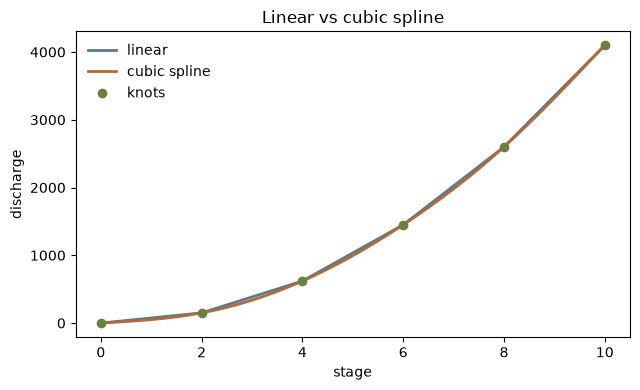

In [11]:
stage = [0, 2, 4, 6, 8, 10]
discharge = [0, 150, 620, 1450, 2600, 4100]
stage_out = np.arange(0, 10.01, 0.25)

linear_q = ch.interpolate(stage, discharge, stage_out, method="linear")
spline_q = ch.interpolate(stage, discharge, stage_out, method="cubic_spline")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(stage_out, linear_q, color="#5b7a8c", linewidth=2, label="linear")
ax.plot(stage_out, spline_q, color="#b06a3b", linewidth=2, label="cubic spline")
ax.plot(stage, discharge, "o", color="#6b7f3f", label="knots")
ax.set_xlabel("stage")
ax.set_ylabel("discharge")
ax.set_title("Linear vs cubic spline")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

At the knots the two agree exactly; between them the straight line always underestimates a convex
stretch of the curve, which is what "linear" is doing here -- connecting the dots rather than
following the curvature the knots themselves imply.

## A linear system

`qr_solve()` mirrors the C# `QRDecomposition::Solve` overloads: Householder QR decomposition
followed by back-substitution, for a vector or a matrix right-hand side. A square system with a
known integer solution is enough to see it work:

In [12]:
a = [[3, 2, -1], [2, -2, 4], [-1, 0.5, -1]]
b = [1, -2, 0]
x = ch.qr_solve(a, b)
print(x)
print(np.array(a) @ x)  # reproduces b

[ 1. -2. -2.]
[ 1.00000000e+00 -2.00000000e+00  1.11022302e-15]


`qr_decomposition()` exposes the `q`/`r` factors directly, and `gauss_jordan()` is the alternative
full-pivot route to the same kind of answer (plus, unlike `qr_solve()`, the matrix inverse itself).

## A power function, evaluated and inverted

`univariate_function()` evaluates the two non-tabular Numerics `IUnivariateFunction`
implementations. `"power"`, $Y = \alpha(X - \xi)^\beta$, is a power law of the shape a rating
curve itself often takes; `inverse=True` evaluates its algebraic inverse instead of the forward
function, which recovers the input exactly on a deterministic call:

In [13]:
discharge_at_stage = ch.univariate_function("power", [5, 2, 0, 3], [6])
stage_at_discharge = ch.univariate_function("power", [5, 2, 0, 3], discharge_at_stage, inverse=True)
print(f"discharge = {discharge_at_stage}, recovered stage = {stage_at_discharge}")

discharge = [180.], recovered stage = [6.]


$5 \times (6 - 0)^2 = 180$, and the inverse recovers $6$ back exactly. `"linear"`,
$Y = \alpha + \beta X$, is the other type; both accept `confidence_level` to evaluate the
non-deterministic path over $\epsilon \sim N(0, \sigma)$ instead.

## Key takeaways

1. `root_find()`'s four methods split into two families: three (`"brent"`, `"bisection"`,
   `"secant"`) need a bracket, `"newton"` needs a derivative and a starting guess. All four solve
   the same problem to different precisions and at different costs.
2. The ten `quadrature()` methods are not interchangeable defaults -- the five fixed rules need
   `steps` set explicitly to compete with the five adaptive ones, which set their own refinement.
3. `quadrature_nd()`'s three methods are a tradeoff between simplicity (`"monte_carlo"`),
   stratified refinement (`"miser"`), and importance sampling (`"vegas"`), and only
   `"monte_carlo"`'s aggregated result is proven to reproduce across every one of R, Python, C++,
   and C#.
4. `target_probability` is what turns Vegas from a general integrator into a rare-event sampler --
   it reconfigures the grid toward the tail rather than requiring you to importance-sample by hand.
5. `interpolate()`'s three methods diverge between knots, not at them; which one is right depends
   on whether the curve you are modeling actually has the smoothness a spline assumes.
6. `qr_solve()`, `qr_decomposition()`, and `gauss_jordan()` all solve `a @ x = b`; they differ in
   what else they hand back (the factors, or the inverse) and in whether `a` must be square.

## Reproduction check

Two halves. The first is a regression on this page's own numbers -- deterministic values, checked
at relative tolerance since floating-point literals typed by hand can land a bit off a computed
value. The second reruns the three `quadrature_nd()` constructs
`fixtures/callback/callback_cross_language.json` itself pins against the real C# library at zero
tolerance, checking only what that fixture asserts: `function_evaluations` and `status` on every
method, the `Result` value additionally on `"monte_carlo"` alone -- Miser's and Vegas's own
floating-point fields are deliberately not checked here for the reason given above.

In [14]:
def near(x, literal, tol=1e-15):
    return abs(x / literal - 1) < tol


root_system = ch.root_find_system(circle_and_line, circle_and_line_jacobian, first_guess=[1, 1])

assert near(brent, 1.4142135623731364)
assert near(newton, 1.4142135623730951)
assert near(root_system[0], 1.4142135623730951)
assert near(decay[-1], 0.82085009767073757736)
assert near(float(ch.quadrature(g, -3, 3)), 0.99730020393673990409)
assert near(float(vegas_p), 0.0023315896197769283606)
assert near(discharge_at_stage[0], 180)
assert near(stage_at_discharge[0], 6)
assert near(x[0], 0.99999999999999888978)
assert near(x[1], -1.9999999999999971134)
assert near(x[2], -1.9999999999999984457)

# The callback_cross_language.json construct: EMITTER-READ from the real C# library.
assert near(float(monte_carlo), 3.4285714285714284)
assert monte_carlo.function_evaluations == 21
assert monte_carlo.status == "Success"
assert miser.function_evaluations == 300
assert miser.status == "None"
assert vegas.function_evaluations == 500
assert vegas.status == "Success"

print("All reproduction checks passed.")

All reproduction checks passed.
